# ERA5 / Aurora boundary injection inspection

This notebook compares the interior ERA5 sample and the same sample after the Aurora-style `inject-inside` boundary replacement.

- Time: `2020-07-01 00:00:00`
- Region: latitude `39.75 -> 5`, longitude `100 -> 144.75`
- Boundary width: `8`
- Variable: `q` at `level=1000` (`q_1000`)

The code below follows the dataset access patterns used by `ERA5TWDatasetforAurora` and `BoundaryConditionDataset_ERA5`, then mirrors the `inject-inside` replacement logic before inference.

/tmp/ipykernel_1454924/2203236569.py:69: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(upper_path) as upper_nc, xr.open_dataset(sfc_path) as sfc_nc:
/tmp/ipykernel_1454924/2203236569.py:69: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attrib

boundary q_1000 shape: (154, 196)
interior q_1000 shape: (140, 180)
after inject q_1000 shape: (140, 180)
boundary crop target shape: (140, 180)
level=1000 index: 0
value range used for plotting: vmin=0.00804756, vmax=0.0206446


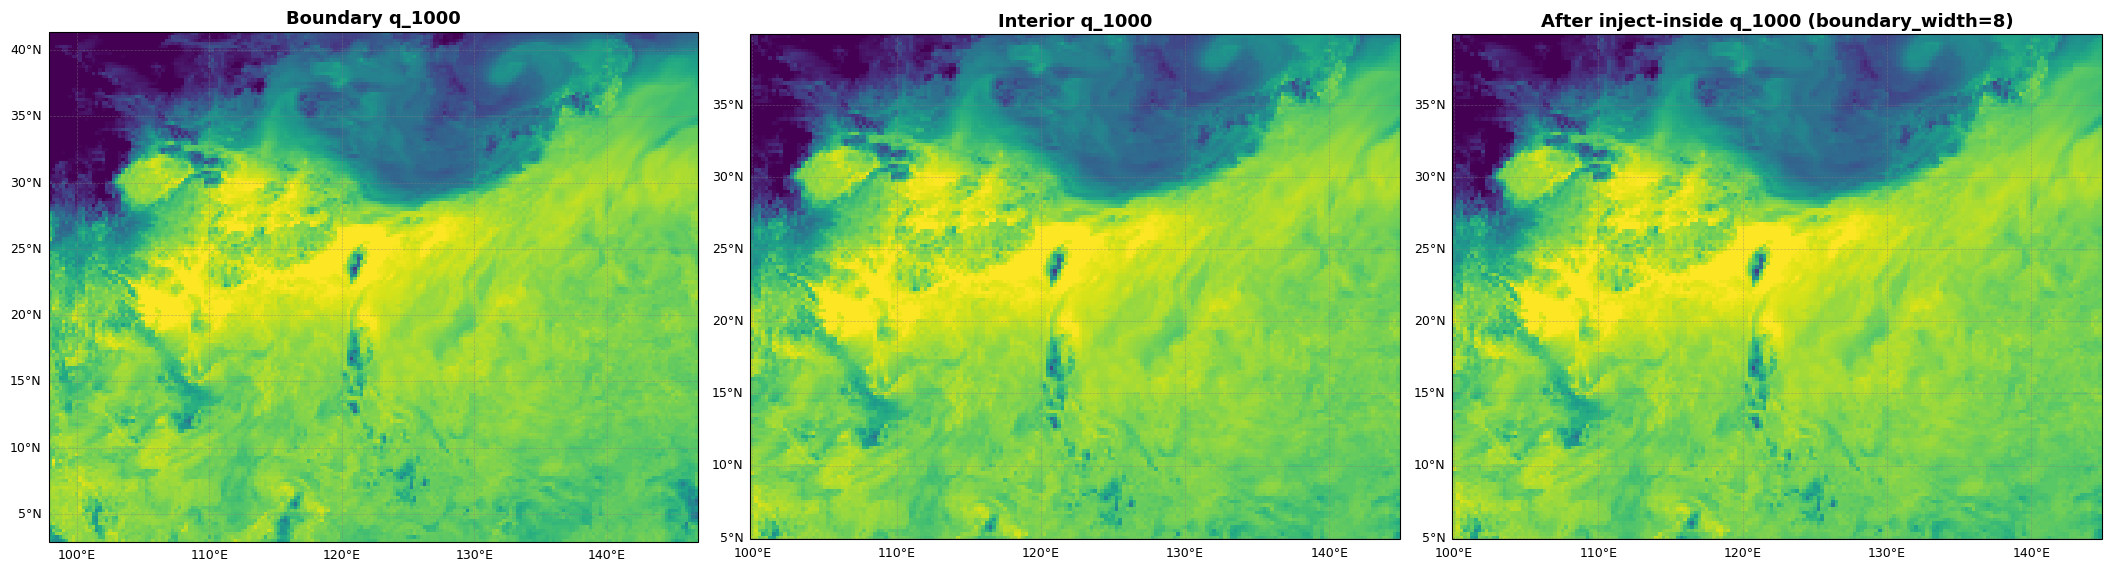

In [4]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

REPO_ROOT = Path("/tmp3/b12902101/Mazu")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from datasets.BoundaryConditionDataset import BoundaryConditionDataset_ERA5

TARGET_TIME = pd.Timestamp("2020-07-01 00:00:00")
DATA_ROOT_DIR = Path("/tmp3/b12902101/era5_tw_forecast_2d")
BOUNDARY_ROOT_DIR = Path("/tmp3/b12902101/era5_tw_forecast_3d")
LATITUDE = (39.75, 5)
LONGITUDE = (100, 144.75)
LEVELS = [1000, 925, 850, 700, 500, 300, 150, 50]
SURFACE_VARIABLES = ["t2m", "u10", "v10", "msl"]
UPPER_VARIABLES = ["u", "v", "t", "q", "z"]
BOUNDARY_WIDTH = 8

boundary_ds = BoundaryConditionDataset_ERA5(
    boundary_root_dir = str(BOUNDARY_ROOT_DIR),
    start_date_hour = TARGET_TIME,
    end_date_hour = TARGET_TIME,
    upper_variables = UPPER_VARIABLES,
    surface_variables = SURFACE_VARIABLES,
    levels = LEVELS,
    latitude = LATITUDE,
    longitude = LONGITUDE,
    boundary_width = BOUNDARY_WIDTH,
    prediction_timedeltas = [0, 6, 12],
    forecast_cycle_hours = 12,
    get_datetime = False,
    enable_pooling = False,
    interp_mode = "forward",
    use_cache = False,
)


def map_var_name_for_aurora(var_name):
    return {
        "t2m": "2t",
        "u10": "10u",
        "v10": "10v",
        "msl": "msl",
    }.get(var_name, var_name)


def build_coord_slice(coord_values, bounds):
    lower = min(bounds)
    upper = max(bounds)
    if coord_values[0] > coord_values[-1]:
        return slice(upper, lower)
    return slice(lower, upper)


def load_era5_interior_sample(root_dir, target_time, latitude, longitude, levels):
    date_folder = target_time.strftime("%Y/%Y%m")
    name = target_time.strftime("%Y%m%d")
    upper_path = root_dir / date_folder / f"{name}_upper.nc"
    sfc_path = root_dir / date_folder / f"{name}_sfc.nc"

    with xr.open_dataset(upper_path) as upper_nc, xr.open_dataset(sfc_path) as sfc_nc:
        upper_nc.load()
        sfc_nc.load()

        level_dim = "pressure_level" if "pressure_level" in upper_nc.dims else "level"
        latitude_slice = build_coord_slice(upper_nc.latitude.values, latitude)
        longitude_slice = build_coord_slice(upper_nc.longitude.values, longitude)

        if "time" in upper_nc.coords and target_time in pd.DatetimeIndex(pd.to_datetime(upper_nc.time.values)):
            upper_nc = upper_nc.sel(time = target_time)
        if "time" in sfc_nc.coords and target_time in pd.DatetimeIndex(pd.to_datetime(sfc_nc.time.values)):
            sfc_nc = sfc_nc.sel(time = target_time)

        if "prediction_timedelta" in upper_nc.dims:
            upper_nc = upper_nc.isel(prediction_timedelta = 0)
        if "prediction_timedelta" in sfc_nc.dims:
            sfc_nc = sfc_nc.isel(prediction_timedelta = 0)

        interior_lat = upper_nc.latitude.sel(latitude = latitude_slice).values
        interior_lon = upper_nc.longitude.sel(longitude = longitude_slice).values

        sample = {"surf_vars": {}, "atmos_vars": {}}
        for surface_var in SURFACE_VARIABLES:
            mapped_name = map_var_name_for_aurora(surface_var)
            file_var = mapped_name if mapped_name in sfc_nc.variables else surface_var
            data_array = sfc_nc[file_var].sel(latitude = latitude_slice, longitude = longitude_slice)
            data_array = data_array.transpose("latitude", "longitude")
            sample["surf_vars"][mapped_name] = torch.as_tensor(data_array.values)

        for upper_var in UPPER_VARIABLES:
            data_array = upper_nc[upper_var].sel(
                {level_dim: levels, "latitude": latitude_slice, "longitude": longitude_slice}
            )
            data_array = data_array.transpose(level_dim, "latitude", "longitude")
            sample["atmos_vars"][upper_var] = torch.as_tensor(data_array.values)

    return sample, interior_lat, interior_lon


def add_batch_dim(sample):
    return {
        "surf_vars": {name: tensor.unsqueeze(0) for name, tensor in sample["surf_vars"].items()},
        "atmos_vars": {name: tensor.unsqueeze(0) for name, tensor in sample["atmos_vars"].items()},
    }


def add_batch_time_dim(sample):
    return {
        "surf_vars": {name: tensor.unsqueeze(0).unsqueeze(0) for name, tensor in sample["surf_vars"].items()},
        "atmos_vars": {name: tensor.unsqueeze(0).unsqueeze(0) for name, tensor in sample["atmos_vars"].items()},
    }


def center_crop_to_shape(tensor, target_height, target_width):
    height = tensor.shape[-2]
    width = tensor.shape[-1]
    if height == target_height and width == target_width:
        return tensor
    start_h = max(0, (height - target_height) // 2)
    start_w = max(0, (width - target_width) // 2)
    return tensor[..., start_h:start_h + target_height, start_w:start_w + target_width]


def align_boundary_batch(boundary_batch, flip_lat, flip_lon):
    if not (flip_lat or flip_lon):
        return boundary_batch
    aligned = {"surf_vars": {}, "atmos_vars": {}}
    for var_dict_name in ("surf_vars", "atmos_vars"):
        for var_name, tensor in boundary_batch[var_dict_name].items():
            if flip_lat:
                tensor = torch.flip(tensor, dims = (-2,))
            if flip_lon:
                tensor = torch.flip(tensor, dims = (-1,))
            aligned[var_dict_name][var_name] = tensor
    return aligned


def replace_boundary_inside(pred_tensor, boundary_tensor, boundary_width):
    if boundary_width <= 0:
        return pred_tensor
    if pred_tensor.dim() == boundary_tensor.dim() + 1:
        boundary_tensor = boundary_tensor.unsqueeze(1)
    if pred_tensor.dim() != boundary_tensor.dim():
        raise ValueError("Boundary tensor rank does not match prediction tensor.")
    updated = pred_tensor.clone()
    bw = boundary_width
    updated[..., :bw, :] = boundary_tensor[..., :bw, :]
    updated[..., -bw:, :] = boundary_tensor[..., -bw:, :]
    updated[..., :, :bw] = boundary_tensor[..., :, :bw]
    updated[..., :, -bw:] = boundary_tensor[..., :, -bw:]
    return updated


def inject_inside_batch(inputs, boundary_batch, boundary_width):
    injected = {"surf_vars": {}, "atmos_vars": {}}
    for var_name, tensor in inputs["surf_vars"].items():
        boundary_tensor = boundary_batch["surf_vars"][var_name].unsqueeze(1).expand(-1, tensor.shape[1], -1, -1)
        injected["surf_vars"][var_name] = replace_boundary_inside(tensor, boundary_tensor, boundary_width)
    for var_name, tensor in inputs["atmos_vars"].items():
        boundary_tensor = boundary_batch["atmos_vars"][var_name].unsqueeze(1).expand(-1, tensor.shape[1], -1, -1, -1)
        injected["atmos_vars"][var_name] = replace_boundary_inside(tensor, boundary_tensor, boundary_width)
    return injected


def select_q_1000(tensor, level_index):
    if tensor.dim() == 3:
        return tensor[level_index]
    if tensor.dim() == 4:
        return tensor[0, level_index]
    if tensor.dim() == 5:
        return tensor[0, 0, level_index]
    raise ValueError(f"Unexpected tensor rank for q: {tensor.dim()}")


interior_sample, interior_lat, interior_lon = load_era5_interior_sample(
    DATA_ROOT_DIR,
    TARGET_TIME,
    LATITUDE,
    LONGITUDE,
    LEVELS,
)
boundary_source = boundary_ds.get_boundary_source(TARGET_TIME)
boundary_step = boundary_ds.get_boundary_at_time_from_source(boundary_source, TARGET_TIME, TARGET_TIME)

level_values = np.asarray(LEVELS)
level_index_candidates = np.where(level_values == 1000)[0]
if level_index_candidates.size == 0:
    raise ValueError(f"Cannot find level=1000 in {level_values.tolist()}")
q_level_index = int(level_index_candidates[0])

boundary_lat = boundary_source["latitude"]
boundary_lon = boundary_source["longitude"]
flip_lat = (interior_lat[0] < interior_lat[-1]) != (boundary_lat[0].item() < boundary_lat[-1].item())
flip_lon = (interior_lon[0] < interior_lon[-1]) != (boundary_lon[0].item() < boundary_lon[-1].item())

inputs = add_batch_time_dim(interior_sample)

boundary_step_display = add_batch_time_dim(boundary_step)
boundary_step_display = align_boundary_batch(boundary_step_display, flip_lat, flip_lon)
q_1000_boundary = select_q_1000(boundary_step_display["atmos_vars"]["q"], q_level_index).detach().cpu().numpy()

boundary_target_height = interior_sample["atmos_vars"]["q"].shape[-2]
boundary_target_width = interior_sample["atmos_vars"]["q"].shape[-1]
boundary_step_for_inject = add_batch_dim(boundary_step)
boundary_step_for_inject = align_boundary_batch(boundary_step_for_inject, flip_lat, flip_lon)
boundary_step_for_inject = {
    "surf_vars": {
        name: center_crop_to_shape(tensor, boundary_target_height, boundary_target_width)
        for name, tensor in boundary_step_for_inject["surf_vars"].items()
    },
    "atmos_vars": {
        name: center_crop_to_shape(tensor, boundary_target_height, boundary_target_width)
        for name, tensor in boundary_step_for_inject["atmos_vars"].items()
    },
}
injected_inputs = inject_inside_batch(inputs, boundary_step_for_inject, BOUNDARY_WIDTH)

q_1000_interior = select_q_1000(interior_sample["atmos_vars"]["q"], q_level_index).detach().cpu().numpy()
q_1000_injected = select_q_1000(injected_inputs["atmos_vars"]["q"], q_level_index).detach().cpu().numpy()

combined = np.concatenate([q_1000_boundary.ravel(), q_1000_interior.ravel(), q_1000_injected.ravel()])
vmin, vmax = np.nanpercentile(combined, [2, 98])
if np.isclose(vmin, vmax):
    vmin = float(np.nanmin(combined))
    vmax = float(np.nanmax(combined))

print(f"boundary q_1000 shape: {q_1000_boundary.shape}")
print(f"interior q_1000 shape: {q_1000_interior.shape}")
print(f"after inject q_1000 shape: {q_1000_injected.shape}")
print(f"boundary crop target shape: {(boundary_target_height, boundary_target_width)}")
print(f"level=1000 index: {q_level_index}")
print(f"value range used for plotting: vmin={vmin:.6g}, vmax={vmax:.6g}")

fig, axes = plt.subplots(
    1,
    3,
    figsize = (21, 6),
    subplot_kw = {"projection": ccrs.PlateCarree()},
    constrained_layout = True,
)

panels = [
    (axes[0], q_1000_boundary, boundary_lat, boundary_lon, "Boundary q_1000"),
    (axes[1], q_1000_interior, interior_lat, interior_lon, "Interior q_1000"),
    (axes[2], q_1000_injected, interior_lat, interior_lon, f"After inject-inside q_1000 (boundary_width={BOUNDARY_WIDTH})"),
]

mesh = None
for ax, data, latitudes, longitudes, title in panels:
    mesh = ax.pcolormesh(
        longitudes,
        latitudes,
        data,
        shading = "nearest",
        cmap = "viridis",
        vmin = vmin,
        vmax = vmax,
        transform = ccrs.PlateCarree(),
    )
    ax.set_title(title, fontsize = 13, fontweight = "bold")
    gl = ax.gridlines(draw_labels = True, linewidth = 0.5, color = "gray", alpha = 0.5, linestyle = "--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

# cbar = fig.colorbar(mesh, ax = axes, orientation = "horizontal", pad = 0.06, shrink = 0.92)
# cbar.set_label("q at 1000 hPa")
plt.show()
